In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
rho = 1
mu = 1
u_in = 2
D = 1
L = 2

In [3]:
# Geometry Definition
vertices = [
    [-1,  0.2], [0,  0.2], [1,  0.8], [1,  0.4], # Top Branch
    [0.2, 0],                                  # Split Point
    [1, -0.4], [1, -0.8], [0, -0.2], [-1, -0.2] # Bottom Branch
]
geom = dde.geometry.Polygon(vertices)

In [4]:
# Boundary Definitions
def boundary_inlet(x, on_boundary):
    # Inlet is at x = -1
    return on_boundary and np.isclose(x[0], -1)

def boundary_outlet_top(x, on_boundary):
    # Top outlet is at x = 1, and y is positive
    return on_boundary and np.isclose(x[0], 1) and (x[1] > 0)

def boundary_outlet_bottom(x, on_boundary):
    # Bottom outlet is at x = 1, and y is negative
    return on_boundary and np.isclose(x[0], 1) and (x[1] < 0)

def boundary_wall(x, on_boundary):
    # Wall is everything on the boundary that ISN'T an inlet or outlet
    is_inlet = np.isclose(x[0], -1)
    is_outlet = np.isclose(x[0], 1)
    return on_boundary and not (is_inlet or is_outlet)

# BC Assignments
# 1. No-slip on Walls (u=0, v=0)
bc_wall_u = dde.DirichletBC(geom, lambda x: 0, boundary_wall, component=0)
bc_wall_v = dde.DirichletBC(geom, lambda x: 0, boundary_wall, component=1)

# 2. Parabolic Inlet Profile (optional, or just const u=1)
def inlet_u_func(x):
    # Parabolic profile: u = u_max * (1 - (y/H)^2)
    # Channel half-width H = 0.2
    return 1.0 * (1 - (x[:, 1:2] / 0.2)**2)

bc_inlet_u = dde.DirichletBC(geom, inlet_u_func, boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom, lambda x: 0, boundary_inlet, component=1)

# 3. Pressure Outlet (p=0 at both outlets)
bc_outlet_top_p = dde.DirichletBC(geom, lambda x: 0, boundary_outlet_top, component=2)
bc_outlet_bot_p = dde.DirichletBC(geom, lambda x: 0, boundary_outlet_bottom, component=2)

# Collect all BCs
bcs = [bc_wall_u, bc_wall_v, bc_inlet_u, bc_inlet_v, bc_outlet_top_p, bc_outlet_bot_p]

In [5]:
def pde(X,Y):
    du_x =dde.grad.jacobian(Y, X, i=0, j=0)
    du_y =dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x =dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y =dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x =dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y =dde.grad.jacobian(Y, X, i=2, j=1)
    
    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    u = Y[:, 0].reshape(-1, 1)
    v = Y[:, 1].reshape(-1, 1)
    
    pde_u = u * du_x + v * du_y + (1/rho) * dp_x - (mu/rho) * (du_xx + du_yy)
    pde_v = u * dv_x + v * dv_y + (1/rho) * dp_y - (mu/rho) * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y
    
    return [pde_u,pde_v,pde_cont]

In [6]:
# Create Data Object
data = dde.data.PDE(
    geom,
    pde, # Use your existing pde function
    bcs,
    num_domain=3000,
    num_boundary=500,
    num_test=500
)

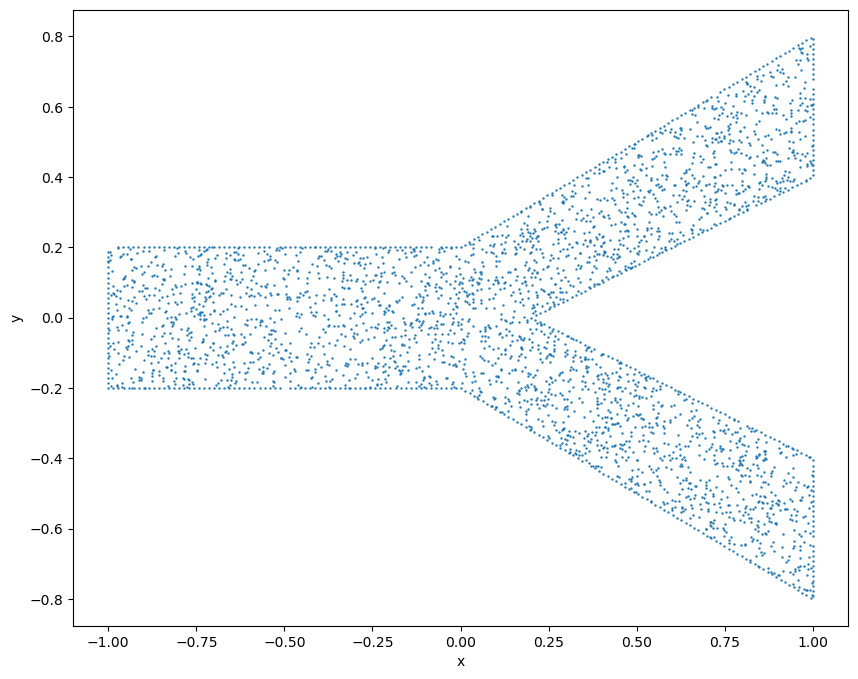

In [7]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0], data.train_x_all[:,1], s= 0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [8]:
net = dde.maps.FNN([2] + [64]*5 + [3] , "tanh", "Glorot uniform")

In [9]:
model = dde.Model(data, net)

# Set weights for Wall BCs (indices 3 and 4) to 100.0
loss_weights = [1, 1, 1, 100, 100, 10, 10, 1, 1] 

model.compile("adam", lr=1e-3, loss_weights=loss_weights)

Compiling model...
'compile' took 0.000430 s



In [10]:
losshistory, train_state = model.train(epochs = 20000)

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [3.23e-02, 6.54e-02, 2.58e-02, 7.35e-01, 1.46e+00, 7.81e+00, 1.22e-01, 4.10e-02, 5.23e-04]    [3.11e-02, 6.26e-02, 2.56e-02, 7.35e-01, 1.46e+00, 7.81e+00, 1.22e-01, 4.10e-02, 5.23e-04]    []  
1000      [1.71e-02, 3.43e-03, 4.34e-01, 3.50e-01, 5.15e-02, 5.77e-01, 2.40e-02, 3.74e-04, 3.34e-04]    [1.18e-02, 2.35e-03, 3.61e-01, 3.50e-01, 5.15e-02, 5.77e-01, 2.40e-02, 3.74e-04, 3.34e-04]    []  
2000      [2.00e-02, 4.59e-03, 2.84e-01, 2.78e-01, 4.66e-02, 5.49e-01, 6.95e-03, 8.30e-05, 1.30e-05]    [2.66e-02, 3.87e-03, 2.41e-01, 2.78e-01, 4.66e-02, 5.49e-01, 6.95e-03, 8.30e-05, 1.30e-05]    []  
3000      [5.58e-02, 4.20e-03, 2.31e-01, 3.00e-01, 4.97e-02, 4.99e-01, 1.83e-03, 1.16e-03, 1.03e-03]    [5.07e-02, 2.42e-03, 2.05e-01, 3.00e-01, 4.97e-02, 4.99e-0

KeyboardInterrupt: 

Compiling model...
'compile' took 0.005491 s

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
20000     [3.16e-03, 2.17e-03, 6.83e-02, 1.39e-03, 1.70e-04, 2.14e-03, 4.15e-05, 2.73e-05, 4.38e-06]    [3.26e-03, 2.25e-03, 7.79e-02, 1.39e-03, 1.70e-04, 2.14e-03, 4.15e-05, 2.73e-05, 4.38e-06]    []  
21000     [4.25e-05, 2.13e-05, 2.44e-04, 2.03e-03, 3.92e-03, 1.03e-04, 5.37e-06, 1.01e-06, 5.32e-07]    [4.42e-05, 1.88e-05, 2.81e-04, 2.03e-03, 3.92e-03, 1.03e-04, 5.37e-06, 1.01e-06, 5.32e-07]    []  
22000     [4.11e-05, 1.95e-05, 2.09e-04, 2.06e-03, 3.71e-03, 7.92e-05, 4.60e-06, 1.10e-06, 2.52e-06]    [3.61e-05, 1.83e-05, 2.34e-04, 2.06e-03, 3.71e-03, 7.92e-05, 4.60e-06, 1.10e-06, 2.52e-06]    []  
23000     [1.82e-05, 1.62e-05, 2.11e-04, 2.06e-03, 3.62e-03, 7.48e-05, 3.61e-06, 1.39e-06, 1.77e-06]    [1.80e-05, 1

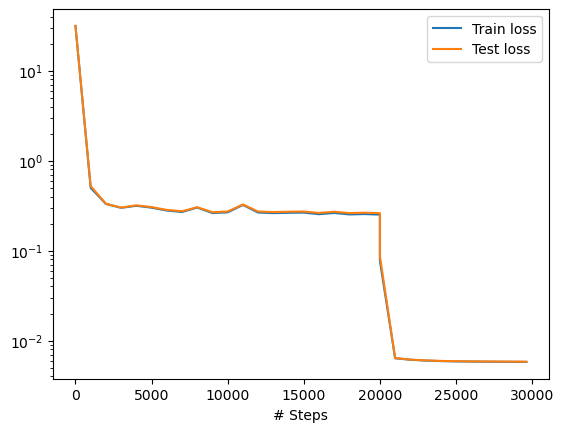

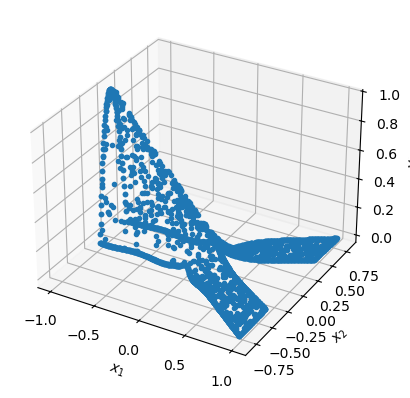

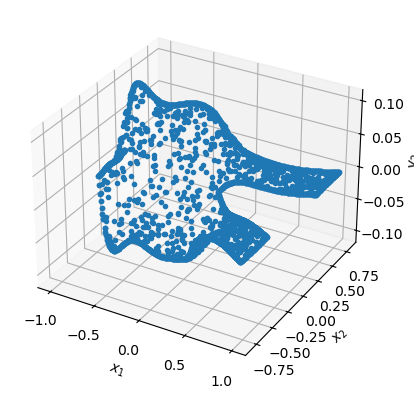

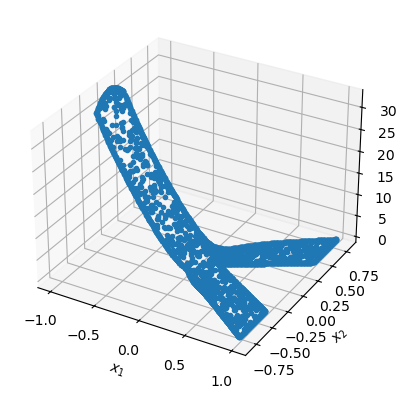

In [11]:
dde.optimizers.config.set_LBFGS_options(maxiter= 10000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [12]:
samples = geom.random_points(500000)
result = model.predict(samples)

Interpolating velocity field for streamlines...


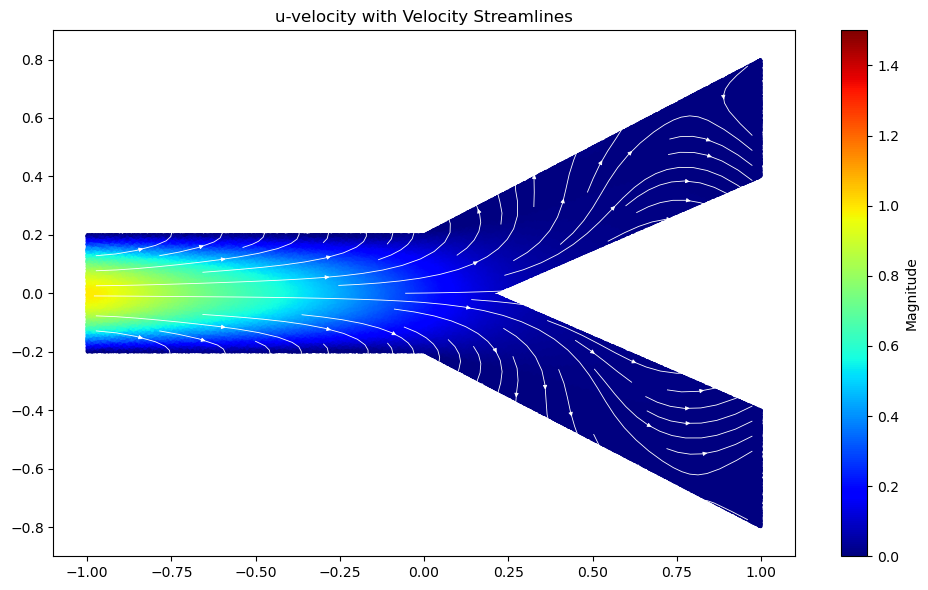

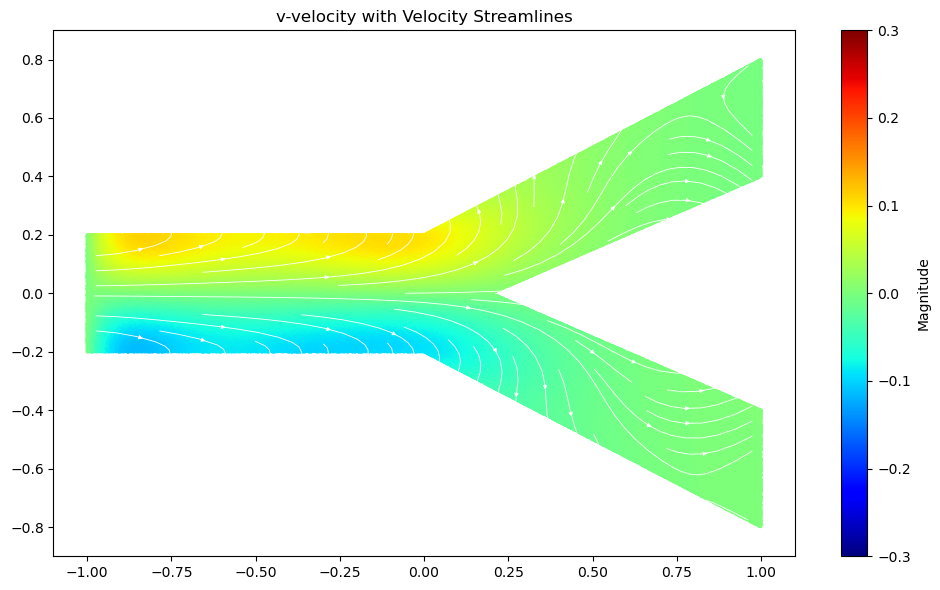

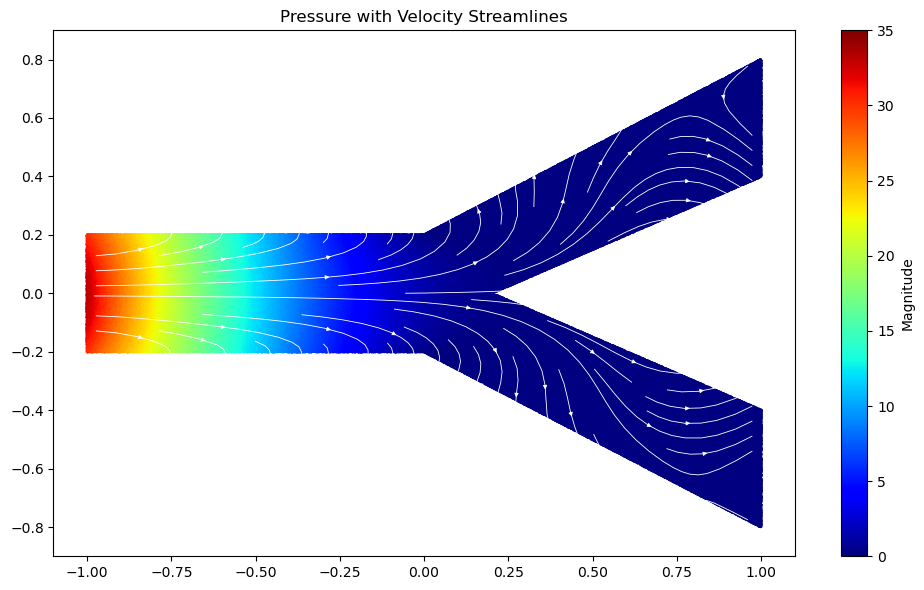

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

# ==========================================
# 1. Pre-compute Grid for Streamlines
# ==========================================
# Define a regular grid covering the domain
grid_x = np.linspace(-1.1, 1.1, 200)
grid_y = np.linspace(-0.9, 0.9, 200)
GridX, GridY = np.meshgrid(grid_x, grid_y)

# Interpolate U and V velocity components onto this grid
# Assuming result[:, 0] is u-velocity and result[:, 1] is v-velocity
print("Interpolating velocity field for streamlines...")
grid_u = griddata(samples, result[:, 0], (GridX, GridY), method='linear')
grid_v = griddata(samples, result[:, 1], (GridX, GridY), method='linear')

# ==========================================
# 2. Plotting Loop with Streamlines
# ==========================================
color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]
field_names = ["u-velocity", "v-velocity", "Pressure"]

for idx in range(3):
    plt.figure(figsize=(10, 6))
    
    # A. The Scalar Field (Color Background)
    plt.scatter(samples[:, 0],
                samples[:, 1],
                c=result[:, idx],
                cmap='jet',
                s=2)
    plt.colorbar(label='Magnitude')
    plt.clim(color_legend[idx])
    
    # B. The Streamlines (Velocity Vector Field)
    # Overlay streamlines on top of the scatter plot
    # color='k' (black) or 'w' (white) usually contrasts best with 'jet'
    plt.streamplot(GridX, GridY, grid_u, grid_v, 
                   color='white', 
                   linewidth=0.6, 
                   arrowsize=0.6, 
                   density=1.2) # Adjust density (higher = more lines)
    
    # C. Limits & Layout
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.9, 0.9)
    plt.title(f"{field_names[idx]} with Velocity Streamlines")
    plt.tight_layout()
    plt.show()

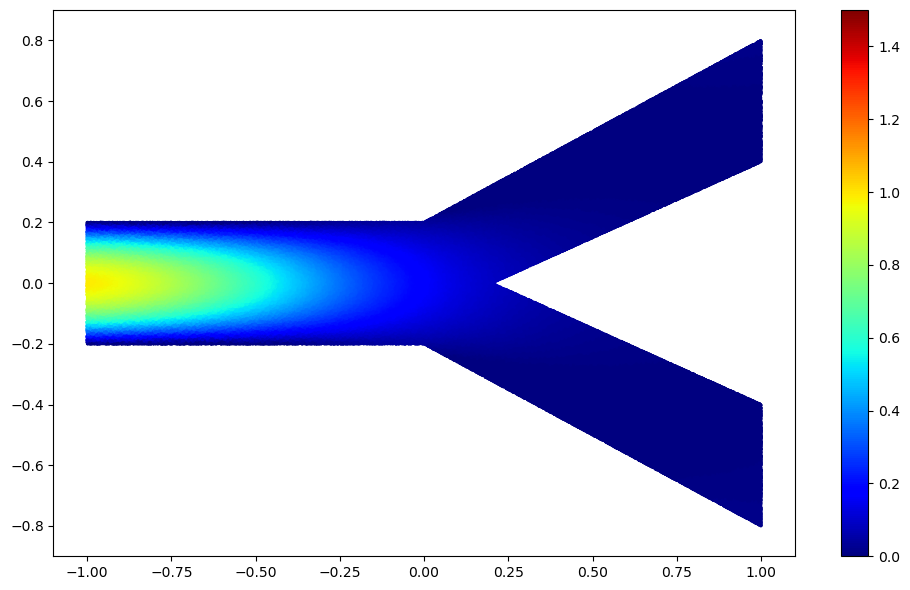

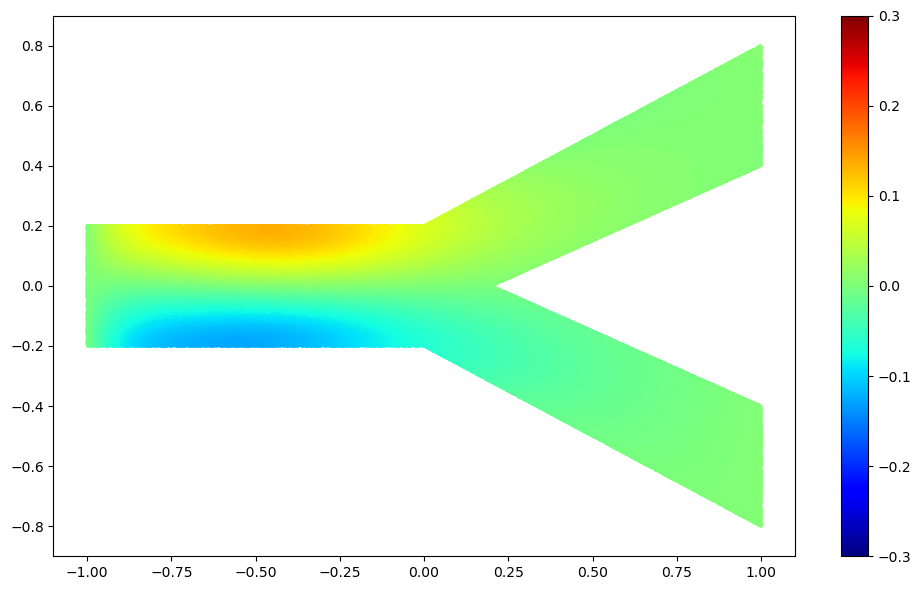

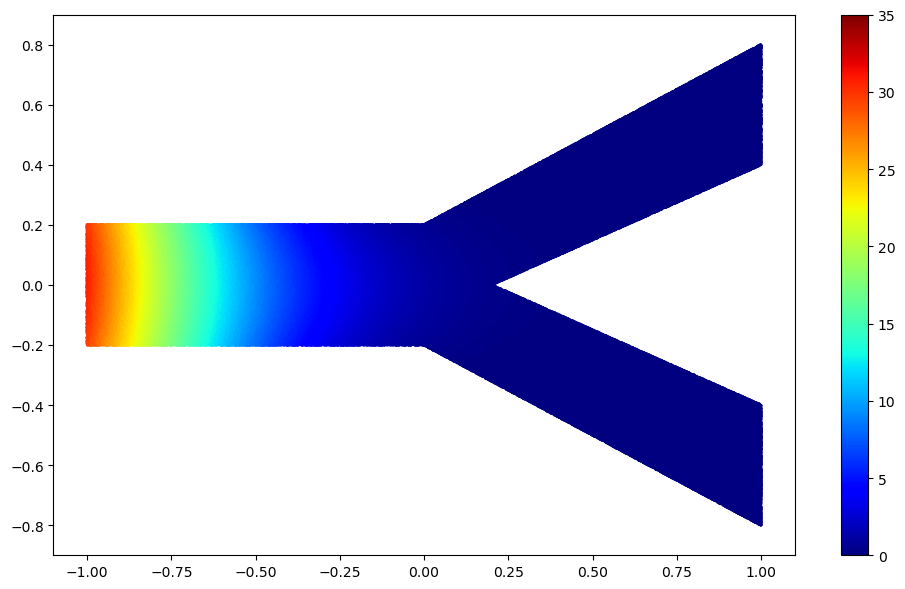

In [15]:
color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]

for idx in range(3):
    plt.figure(figsize=(10, 6)) # Adjusted figsize for the Y-shape aspect ratio
    plt.scatter(samples[:, 0],
                samples[:, 1],
                c=result[:, idx],
                cmap='jet',
                s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    
    # Update limits to match the Y-shaped polygon bounding box
    plt.xlim(-1.1, 1.1)  # Slightly larger than [-1, 1]
    plt.ylim(-0.9, 0.9)  # Slightly larger than [-0.8, 0.8]
    
    plt.tight_layout()
    plt.show()

In [33]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. Constants (Y-Shape Geometry)
# ==========================================
X_INLET  = -1.0
X_OUTLET =  1.0
Y_INLET_BOTTOM = -0.2
Y_INLET_TOP    =  0.2

# Physics
FLUID_RHO = 1.0       
FLUID_MU  = 1.0      
PARTICLE_D = 0.01     
PARTICLE_RHO = 10.0   

# Derived
PARTICLE_A = np.pi * (PARTICLE_D / 2)**2
PARTICLE_MASS = PARTICLE_RHO * (4/3) * np.pi * (PARTICLE_D / 2)**3

# ==========================================
# 2. Physics & Collision Logic
# ==========================================
def get_drag_coefficient(Re):
    if Re <= 0: return 0.0
    if Re < 1000: return (24.0 / Re) * (1 + 0.15 * (Re**0.687))
    return 0.44

def particle_momentum_eq(t, state, model):
    xp, yp, up, vp = state
    
    # Predict Fluid Velocity
    pos_tensor = np.array([[xp, yp]])
    fluid_vars = model.predict(pos_tensor)
    ug, vg = fluid_vars[0, 0], fluid_vars[0, 1]
    
    # Drag Force
    u_rel, v_rel = ug*5 - up, vg*5 - vp
    v_rel_mag = np.sqrt(u_rel**2 + v_rel**2)
    Re_p = (FLUID_RHO * v_rel_mag * PARTICLE_D) / FLUID_MU
    Cd = get_drag_coefficient(Re_p)
    coeff = (0.5 * Cd * PARTICLE_A * FLUID_RHO * v_rel_mag) / PARTICLE_MASS
    
    return [up, vp, coeff * u_rel, coeff * v_rel]

# --- COLLISION EVENTS ---

def outlet_event(t, state, model):
    """Trigger when particle reaches X = 1.0"""
    return state[0] - X_OUTLET
outlet_event.terminal = True
outlet_event.direction = 1

def wall_collision_event(t, state, model):
    """
    Trigger if particle hits ANY wall (Outer or Inner Wedge).
    Returns negative if collision occurs.
    """
    x, y = state[0], state[1]
    
    # 1. Check Outer Walls (Top/Bottom Limits)
    # Top Outer Wall: (0, 0.2) to (1, 0.8) -> y = 0.6*x + 0.2
    # Bottom Outer Wall: (0, -0.2) to (1, -0.8) -> y = -0.6*x - 0.2
    if x > 0:
        dist_top = (0.6 * x + 0.2) - y
        dist_bot = y - (-0.6 * x - 0.2)
    else:
        dist_top = 0.2 - y
        dist_bot = y - (-0.2)

    # 2. Check Inner Wedge (The Splitter)
    # Wedge starts at x > 0.2. 
    # Top Inner: y = 0.5 * (x - 0.2)
    # Bottom Inner: y = -0.5 * (x - 0.2)
    # Particle is safe if |y| > 0.5 * (x - 0.2)
    if x > 0.2:
        wedge_boundary_y = 0.5 * (x - 0.2)
        dist_wedge = abs(y) - wedge_boundary_y # Negative if inside wedge
    else:
        dist_wedge = 1.0 # Safe (no wedge here)

    # Return the smallest distance (if any is < 0, collision happened)
    return min(dist_top, dist_bot, dist_wedge)

wall_collision_event.terminal = True 

# ==========================================
# 3. Tracing & Plotting
# ==========================================
def trace_and_plot_particles(model, n_particles=15, t_max=8.0):
    print(f"Releasing {n_particles} particles...")
    plt.figure(figsize=(10, 6))
    
    # --- Draw Geometry ---
    plt.plot([-1, 0, 1], [0.2, 0.2, 0.8], 'k-', lw=2)  # Outer Top
    plt.plot([-1, 0, 1], [-0.2, -0.2, -0.8], 'k-', lw=2) # Outer Bottom
    plt.plot([0.2, 1], [0, 0.4], 'k-', lw=2)    # Inner Top
    plt.plot([0.2, 1], [0, -0.4], 'k-', lw=2)   # Inner Bottom
    plt.plot([-1, -1], [-0.2, 0.2], 'k--', label='Inlet')

    # Release points
    start_y = np.linspace(Y_INLET_BOTTOM + 0.02, Y_INLET_TOP - 0.02, n_particles)
    
    for y0 in start_y:
        init = [X_INLET, y0, 0.0, 0.0] # x, y, u, v
        
        sol = solve_ivp(
            fun=particle_momentum_eq,
            t_span=[0, t_max],
            y0=init,
            args=(model,),
            # Stop at Outlet OR Wall Collision
            events=[outlet_event, wall_collision_event], 
            rtol=1e-4, atol=1e-6,
            dense_output=True
        )
        
        x, y = sol.y[0], sol.y[1]
        
        # Color Logic: Blue = Exit, Red = Wall Hit, Green = Still in domain
        color = 'green'
        status_label = ""
        
        if sol.status == 1: # Event triggered
            # Check which event triggered it
            if abs(x[-1] - X_OUTLET) < 0.05: 
                color = 'blue'  # Reached Outlet
            else:
                color = 'red'   # Hit Wall
        
        plt.plot(x, y, '-', color='gray', alpha=0.6)
        plt.scatter(x[-1], y[-1], c=color, s=20, zorder=3)

    plt.title("Particle Tracing (Blue=Exit, Red=Wall Hit)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.9, 0.9)
    plt.tight_layout()
    plt.show()

Tracing 5 particles...


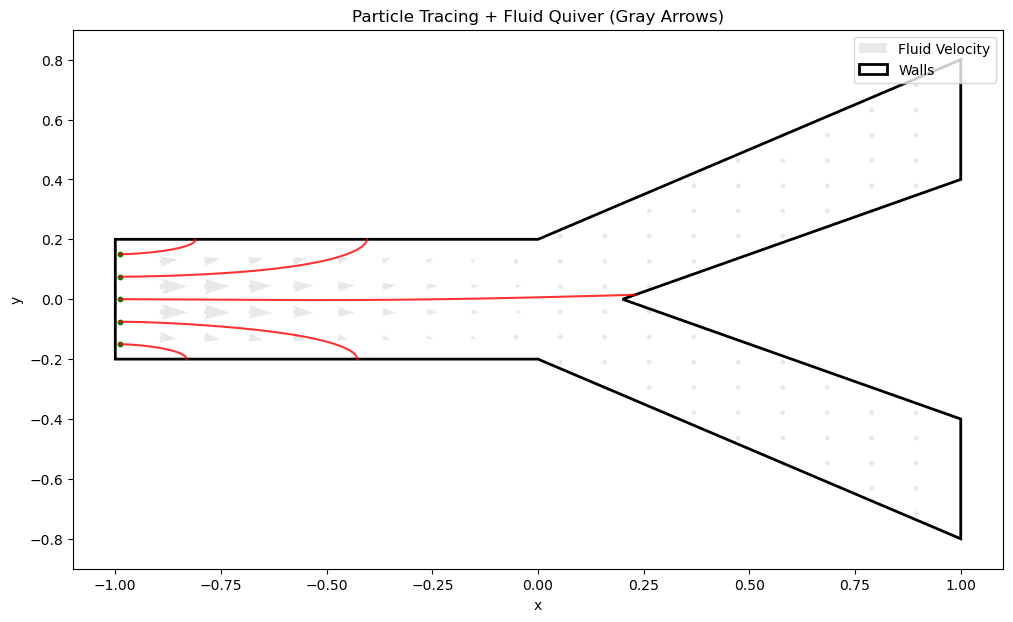

In [34]:
# Run
trace_with_diagnostics(model, n_particles=5)
